# Solution (1)

#### Import

In [51]:
import numpy as np
import matplotlib.pyplot as plt

#### Objective functions


In [52]:
def objective_functions(r, h):
    S = np.pi * r * np.sqrt(r**2 + h**2)
    T = np.pi * r * (r + np.sqrt(r**2 + h**2))
    return S, T

#### Constraint function

In [53]:
def constraint_function(r, h):
    V = (np.pi * r**2 * h) / 3
    return V > 200

#### Find solutions

In [54]:

feasible_r = []
feasible_h = []
feasible_S = []
feasible_T = []

for r in np.linspace(0, 10, 100):
    for h in np.linspace(0, 20, 100):
        S, T = objective_functions(r, h)

        if constraint_function(r, h):
            feasible_r.append(r)
            feasible_h.append(h)
            feasible_S.append(S)
            feasible_T.append(T)

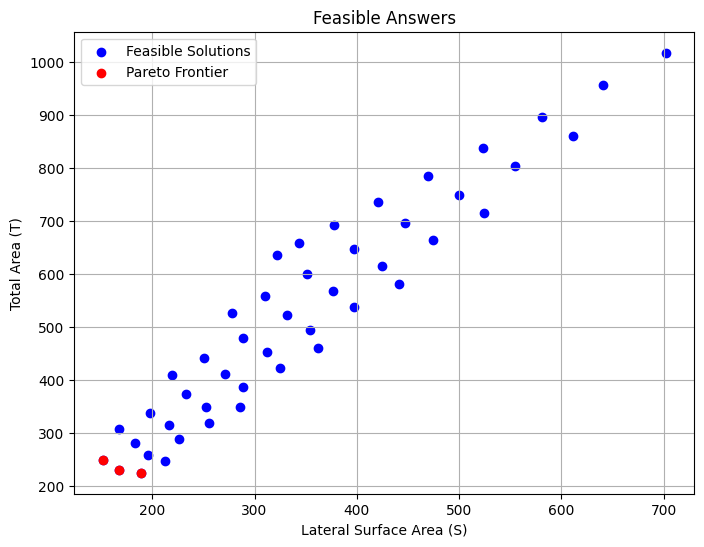

In [66]:
feasible_r = []
feasible_h = []
feasible_S = []
feasible_T = []

for r in np.linspace(0, 10, 10):
    for h in np.linspace(0, 20, 10):
        S, T = objective_functions(r, h)

        if constraint_function(r, h):
            feasible_r.append(r)
            feasible_h.append(h)
            feasible_S.append(S)
            feasible_T.append(T)

feasible_S = np.array(feasible_S)
feasible_T = np.array(feasible_T)


pareto_frontier_indices = []
for i in range(len(feasible_S)):
    is_dominated = False
    for j in range(len(feasible_S)):
        if i != j and feasible_S[i] >= feasible_S[j] and feasible_T[i] >= feasible_T[j]:
            is_dominated = True
            break
    if not is_dominated:
        pareto_frontier_indices.append(i)

# Extract the Pareto frontier solutions
pareto_frontier_S = feasible_S[pareto_frontier_indices]
pareto_frontier_T = feasible_T[pareto_frontier_indices]

plt.figure(figsize=(8, 6))
plt.scatter(feasible_S, feasible_T, color='blue', label='Feasible Solutions')
plt.scatter(pareto_frontier_S, pareto_frontier_T, color='red', label='Pareto Frontier')
plt.xlabel('Lateral Surface Area (S)')
plt.ylabel('Total Area (T)')
plt.title('Feasible Answers')
plt.legend()
plt.grid(True)
plt.show()


Optimum Solution: S = 189.41, T = 224.32


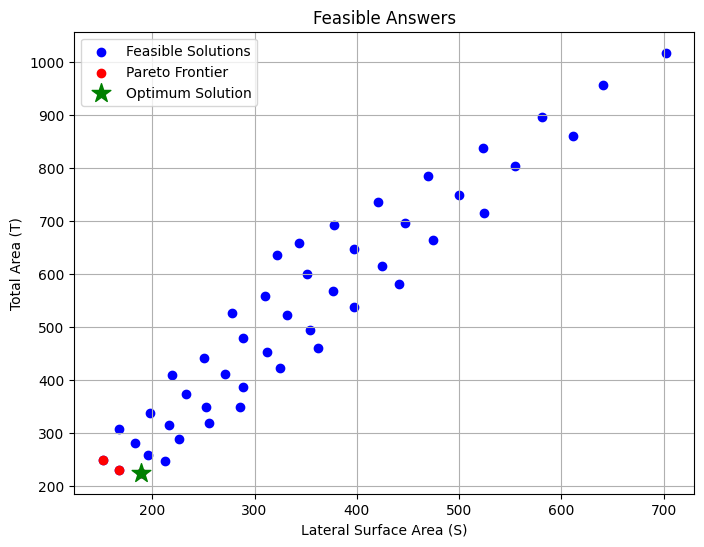

In [67]:
# Find the index of the solution with the minimum total area
min_T_index = np.argmin(pareto_frontier_T)

# Extract the corresponding lateral surface area and total area
optimum_S = pareto_frontier_S[min_T_index]
optimum_T = pareto_frontier_T[min_T_index]

print(f"Optimum Solution: S = {optimum_S:.2f}, T = {optimum_T:.2f}")

plt.figure(figsize=(8, 6))
plt.scatter(feasible_S, feasible_T, color='blue', label='Feasible Solutions')
plt.scatter(pareto_frontier_S, pareto_frontier_T, color='red', label='Pareto Frontier')
plt.scatter(optimum_S, optimum_T, color='green', marker='*', s=200, label='Optimum Solution')
plt.xlabel('Lateral Surface Area (S)')
plt.ylabel('Total Area (T)')
plt.title('Feasible Answers')
plt.legend()
plt.grid(True)
plt.show()

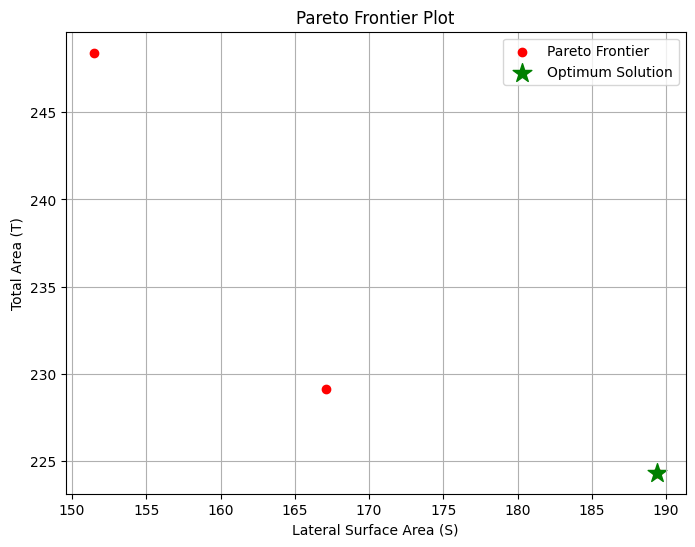

In [68]:
# Plot Pareto frontier only
plt.figure(figsize=(8, 6))
plt.scatter(pareto_frontier_S, pareto_frontier_T, color='red', label='Pareto Frontier')
plt.scatter(optimum_S, optimum_T, color='green', marker='*', s=200, label='Optimum Solution')
plt.xlabel('Lateral Surface Area (S)')
plt.ylabel('Total Area (T)')
plt.title('Pareto Frontier Plot')
plt.legend()
plt.grid(True)
plt.show()

# Solution(2) - Pymoo library



In [7]:
!pip install -U pymoo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 14.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.1/249.1 kB 20.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 14.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 24.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for grapheme: filename=grapheme-0.6.0-py3-none-any.whl size=210078 sha256=699aa6b990b400219a8f565eb4a1bddf20e38c8767d09c31c67f4dace7ea6b27
  Stored in directory: /root/.cache/pip/wheels/01/e1/49/37e6bde9886439057450c494a79b0bef8bbe897a54aebfc757
Successfully built grapheme


In [8]:
!pip install git+https://github.com/msu-coinlab/pymoo.git

  Cloning https://github.com/msu-coinlab/pymoo.git to /tmp/pip-req-build-h8hfvw62
  Running command git clone --filter=blob:none --quiet https://github.com/msu-coinlab/pymoo.git /tmp/pip-req-build-h8hfvw62
  Resolved https://github.com/msu-coinlab/pymoo.git to commit 78993eedad0d4d8c026d133071d1aab062bf4014
  Preparing metadata (setup.py) ... done
  Created wheel for pymoo: filename=pymoo-0.6.0.1-cp310-cp310-linux_x86_64.whl size=3614054 sha256=1dc314c3e4d16f2e71c4165175d87a18f1eca555ab5aca61d4940cdc6dc8ef93
  Stored in directory: /tmp/pip-ephem-wheel-cache-2q5gf_d8/wheels/9f/88/ad/010bd246f26fa0906fb2964fc7629bfbfdeaf011e72b4a93f4
Successfully built pymoo
  Attempting uninstall: pymoo
    Found existing installation: pymoo 0.6.1.1
    Uninstalling pymoo-0.6.1.1:
      Successfully uninstalled pymoo-0.6.1.1


In [19]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.problems import get_problem
from pymoo.optimize import minimize
from pymoo.visualization.scatter import Scatter
import numpy as np
from pymoo.core.problem import Problem
import matplotlib.pyplot as plt
from pymoo.gradient.toolbox import column_stack

In [20]:
from pymoo.problems.multi import OSY
%psource OSY

In [82]:
class ConesPB(Problem):
    def __init__(self):
        super().__init__(n_var = 2, n_obj = 2, n_ieq_constr = 1, xl= np.array([0, 0 ]), xu = np.array([10, 20]), vtype = float)


    def _evaluate(self, x, out, *args, **kwargs):
        r, h = x[:, 0], x[:, 1]
        s = np.sqrt(r ** 2 + h ** 2)

        B = np.pi * (r ** 2)
        S = np.pi * r * s
        T = B + S
        out["F"] = column_stack([S, T])

        V = (np.pi / 3) * (r ** 2) * h
        out["G"] = (-(1 / 200) * (V - 200))



    def calculate_pareto_front(self):
        algorithm = NSGA2(pop_size = 10)
        res = minimize(self, algorithm, termination = ('n_gen', 1))
        pareto_front_indices = self.find_pareto_front(res.F)

        return res.X[pareto_front_indices], res.F[pareto_front_indices]


    def find_pareto_front(self, objectives):
        n = len(objectives)
        is_pareto = np.ones(n, dtype=bool)

        for i in range(n):
            for j in range(n):
                if i != j and all(objectives[j] <= objectives[i]):
                    is_pareto[i] = 0
                    break

        return np.where(is_pareto)[0]

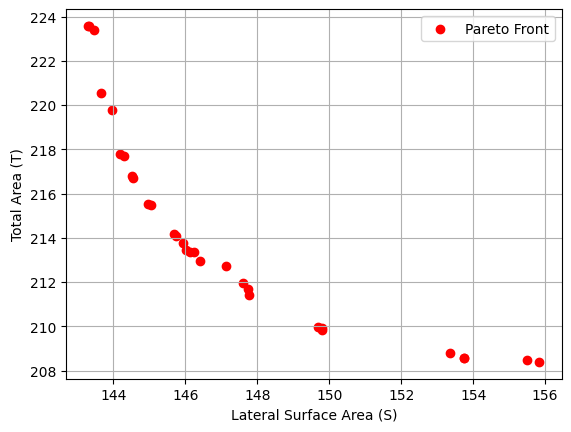

In [93]:
cone_problem = ConesPB()

algorithm = NSGA2(pop_size=100)
result = minimize(cone_problem, algorithm, termination=('n_gen', 100))


decision_variables = result.X
objective_values = result.F


pareto_front_indices = cone_problem.find_pareto_front(objective_values)
pareto_front_decisions = decision_variables[pareto_front_indices]
pareto_front_objectives = objective_values[pareto_front_indices]


plt.scatter(pareto_front_objectives[:, 0], pareto_front_objectives[:, 1], color="red", marker="o", label="Pareto Front")
plt.xlabel("Lateral Surface Area (S)")
plt.ylabel("Total Area (T)")
plt.legend()
plt.grid(True)
plt.show()